In [9]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
# sys.path.append('../../../')
# from mount_drive import mount_s_drive

In [10]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from eICUUtil import *

In [11]:
def getCovariatePreprocessor(aKeepColumns):
    return ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

In [20]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=10)
    myImputer.set_output(transform="pandas")
    myCovariates = getCovariatePreprocessor(['bin__' + 'Hypothermia'])
    myImputer.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor), ('imputer', myImputer)]

In [57]:
columns= [
    'patientunitstayid','gender','age','bmi',
    'nurse_first_Non-Invasive BP Systolic',
    'nurse_first_Non-Invasive BP Diastolic',
    'nurse_first_Non-Invasive BP Mean',
    'nurse_first_Heart Rate',
    'nurse_first_O2 Saturation',
    'nurse_first_Temperature (C)',
    'lab_first_Respiratory Rate',
    'lab_first_FiO2',
    'nurse_first_GCS Total',
    'nurse_first_Motor','FirstGCS','LastGCS','LastGCS15',
    'nurse_first_QTc',
    'lab_first_pH','lab_first_paO2','lab_first_paCO2',
    'lab_first_bicarbonate','lab_first_lactate',
    'lab_first_WBC x 1000','lab_first_Hgb','lab_first_platelets x 1000',
    'lab_first_sodium','lab_first_potassium','lab_first_BUN',
    'lab_first_creatinine','lab_first_calcium','lab_first_magnesium',
    'lab_first_glucose','lab_first_troponin - I','lab_first_troponin - T',
    'diagnosis_initial rhythm: ventricular fibrillation',
    'diagnosis_ventricular fibrillation',
    'diagnosis_ventricular tachycardia',
    'diagnosis_initial rhythm: ventricular tachycardia',
    'diagnosis_initial rhythm: pulseless electrical activity',
    'diagnosis_initial rhythm: asystole',
    # 'FirstMGCS',
    'hypothermia_time',
    'Hypothermia'
]


In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'Hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')
    myPredictorsDf['hypothermia_time'].fillna(0,inplace=True)
    # Preprocessing
    # print(myPredictorsDf['hypothermia_time'])
    myFilter = (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
    myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime']) #& (myPredictorsDf['FirstMGCSTime'] < 360)
    myPredictorsDf.loc[myPredictorsDf['FirstGCS'] == 'Unable to score due to medication', 'FirstGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['FirstMGCS'] == 'Unable to score due to medication', 'FirstMGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['LastMGCS'] == 'Unable to score due to medication', 'LastMGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['LastGCS'] == 'Unable to score due to medication', 'LastGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
    myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
    myPredictorsDf.LastGCS15 = 0
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf.nurse_first_Motor != 6)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myFilter & myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x]

    # Get output data
    myXValue = myPredictorsDf.drop(columns= myColumns + ['FirstGCS',
                                                         'LastMGCSTime', 
                                                         'FirstMGCSTime', 'LastMGCSPositive', 'LastMGCS' , 
                                                         'apacheadmissiondx', 'hospitaladmittime24', 
                                                         'FirstGCSTime', 'LastGCSTime', 'LastGCS', 
                                                         'hospitaldischargestatus', 
                                                         'LastGCS15', 'hospitaladmitsource', 
                                                         'DeathAtDischarge', 'patientunitstayid'])
    # myXValue = myXValue[columns]
    myXValue = myXValue
    # myXValue.FirstGCS = myXValue.FirstGCS.astype(float)
    # myXValue.FirstMGCS = myXValue.FirstMGCS.astype(float)
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [59]:
myPredictorsDf, X_train, X_test, y_train, y_test = \
            getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', 
                                     aTreatmentColumn = 'Hypothermia', 
                                     aDropColumns =[]) 

/tmp/ipykernel_1650498/3679168424.py:6: DtypeWarning: Columns (2188,2190) have mixed types. Specify dtype option on import or set low_memory=False.
  myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')
/tmp/ipykernel_1650498/3679168424.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  myPredictorsDf['hypothermia_time'].fillna(0,inplace=True)


In [60]:
columns_filter = np.unique([x for x in columns if x in X_test.columns])

X_train = X_train[columns_filter]
X_test = X_test[columns_filter]

In [61]:
# def getDefaultPipelineSteps(X_train):
#     myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
#     myBinaryColumns = X_train.columns[X_train.nunique() == 2]
#     myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
#     return [('preprocessor', myPreprocessor), ('imputer', KNNImputer(n_neighbors=10)), \
#             ('sfs', SFS(estimator = XGBClassifier(max_depth = 10, n_estimators = 100, n_jobs=-1), 
#                         verbose =2, n_jobs=-1, k_features=50, forward=True, floating=True, cv=5))]

In [62]:
DefaultGrid = [
    {
        'clf': [XGBClassifier(eval_metric='logloss')],
        'clf__n_estimators': [25, 50, 100], 
        'clf__max_depth': [2, 5, 10]
    },
    # {
    #     'clf': [XGBClassifier(eval_metric='logloss')],
    #     'clf__n_estimators': [50], 
    #     'clf__max_depth': [10]
    # }
    # {
    #     'clf': [DecisionTreeClassifier()],
    #     'clf__max_depth': [2, 5, 20, 50, None],
    #     'clf__class_weight': [None, 'balanced']
    # },
    # {
    #     'clf': [LogisticRegression(), SVC(probability=True)],
    #     'clf__C': [0.01, 0.1, 1, 10, 100]
    # }
    # {
    #     'clf': [KerasClassifier(model=build_model, epochs=30, batch_size=32, verbose=1)]
    # }
]
def gridSearchKFoldClassification(X_train, X_test, y_train, y_test, aScore = 'roc_auc', aGrid = DefaultGrid):
    kf = StratifiedKFold(n_splits=5, shuffle=True)
    myPipelineSteps = getDefaultPipelineSteps(X_train = X_train)
    myPipelineSteps.append(('clf', XGBClassifier()))
    myPipeline = Pipeline(myPipelineSteps)
    myGridSearchCv = GridSearchCV(myPipeline, aGrid, cv=kf, scoring=aScore, n_jobs=-1, verbose=3)
    myGridSearchCv.fit(X_train, y_train)
    myBestModel = myGridSearchCv.best_estimator_
    y_pred_proba = myBestModel.predict_proba(X_test)[:, 1]
    y_pred = myBestModel.predict(X_test)
    print(f'Best parameters: {myGridSearchCv.best_params_}')
    print(f'Best cross val {aScore} score: {myGridSearchCv.best_score_:.4f}')
    print(f'Area under the receiver operating curve on test set is {roc_auc_score(y_test, y_pred_proba):.4f}')
    print(f'Accuracy score on test set is {accuracy_score(y_test, y_pred):.4f}')
    return myGridSearchCv
myGridSearchCv = gridSearchKFoldClassification(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='roc_auc', aGrid = DefaultGrid)
myBestModel = myGridSearchCv.best_estimator_

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END clf=XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...), clf__max_depth=50, clf__n_estimators=100;, score=nan total time=   0.2s
[CV 4/5] END clf=XGBClassifier(base_score=None, booster=None, callback

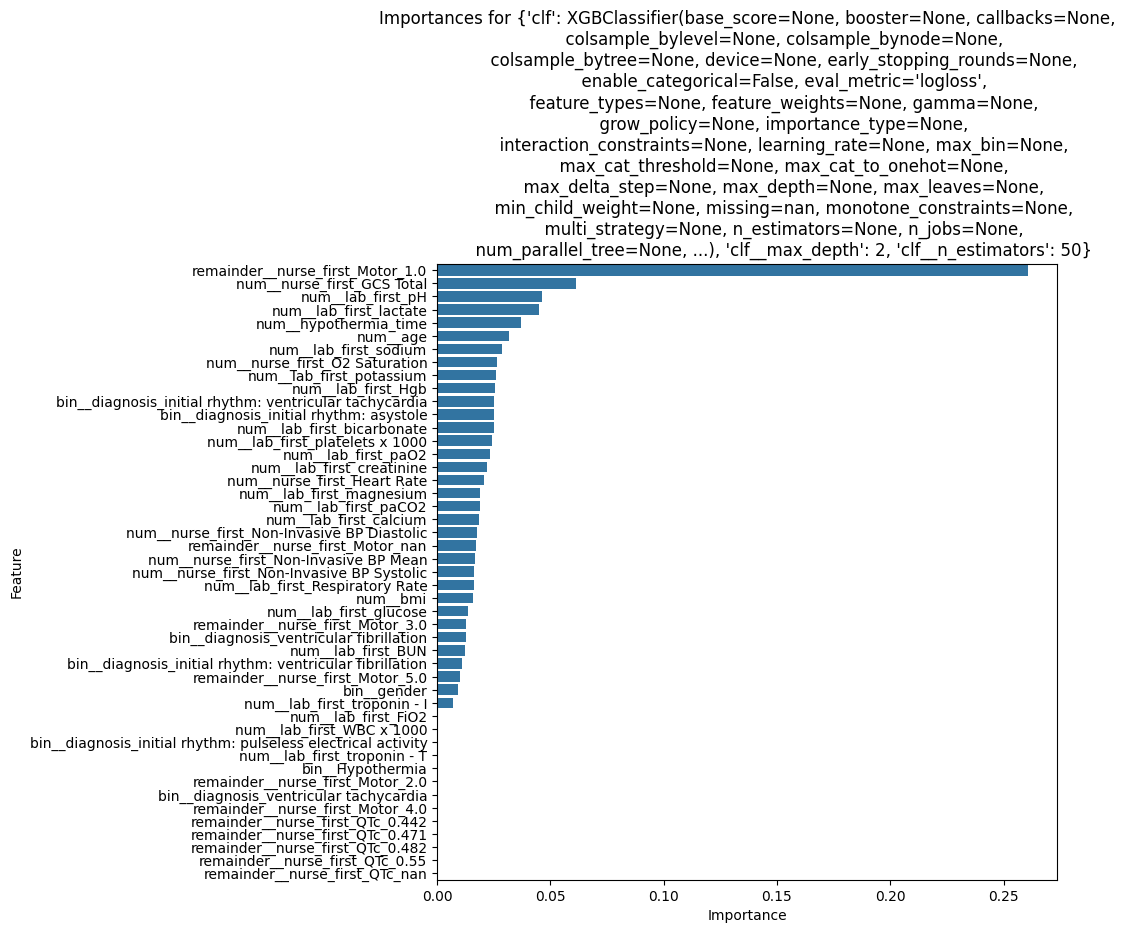

In [63]:
myFeatureImportancesDf = getTopFeatures(myGridSearchCv, list(myBestModel.named_steps.imputer.get_feature_names_out()), X_train, y_train)

In [66]:
# list(y_test)

In [67]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
y_pred_prob = myBestModel.predict_proba(X_test)[:, 1]
def bootstrap_auc_ci(y_true, y_score, n_bootstraps=2000, seed=42):
    rng = np.random.RandomState(seed)
    aucs = []

    for _ in range(n_bootstraps):
        idx = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue  # skip invalid bootstrap
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))

    aucs = np.array(aucs)
    return (
        np.mean(aucs),
        np.percentile(aucs, 2.5),
        np.percentile(aucs, 97.5),
    )

auc, ci_low, ci_high = bootstrap_auc_ci(np.array(y_test), y_pred_prob)
print(f"AUC = {auc:.3f} (95% CI {ci_low:.3f}–{ci_high:.3f})")


AUC = 0.745 (95% CI 0.701–0.785)


In [71]:
myFeatureImportancesDf[myFeatureImportancesDf.Feature == 'bin__Hypothermia']

,Feature,Importance
28,bin__Hypothermia,0.0


[CV 5/5] END clf=XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...), clf__max_depth=2, clf__n_estimators=100;, score=0.667 total time=   0.3s
[CV 2/5] END clf=XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_byn

In [70]:
getTreatmentEffectDiff(aX = X_train, aY = y_train.reset_index().drop(columns='index'), aModel = myBestModel, \
                       aCategory = 'LastMGCSPositive', aGroup = 'Hypothermia', aUseNeuralNetwork = False, aByGroup =False)

No effect difference


TypeError: object of type 'int' has no len()

In [25]:
getTreatmentEffectDiff(aX = X_train, aY = y_train.reset_index().drop(columns='index'), aModel = myBestModel, \
                       aCategory = 'LastMGCSPositive', aGroup = 'treatment_hypothermia', aUseNeuralNetwork = False, aByGroup =False)

No effect difference


TypeError: object of type 'int' has no len()

In [28]:
SFS(estimator = XGBClassifier(max_depth = 50, n_estimators = 200))

SequentialFeatureSelector(estimator=XGBClassifier(base_score=None, booster=None,
                                                  callbacks=None,
                                                  colsample_bylevel=None,
                                                  colsample_bynode=None,
                                                  colsample_bytree=None,
                                                  device=None,
                                                  early_stopping_rounds=None,
                                                  enable_categorical=False,
                                                  eval_metric=None,
                                                  feature_types=None,
                                                  gamma=None, grow_policy=None,
                                                  importance_type=None,
                                                  interaction_constraints=None,
                                                  learning_rate=None,
                                                  max_bin=None,
                                                  max_cat_threshold=None,
                                                  max_cat_to_onehot=None,
                                                  max_delta_step=None,
                                                  max_depth=50, max_leaves=None,
                                                  min_child_weight=None,
                                                  missing=nan,
                                                  monotone_constraints=None,
                                                  multi_strategy=None,
                                                  n_estimators=200, n_jobs=None,
                                                  num_parallel_tree=None,
                                                  random_state=None, ...),
                          scoring='accuracy')

In [75]:
myPredictorsDf[myPredictorsDf['treatment_hypothermia'] == 1][['treatment_hypothermia', 'Hypothermia']].sum()

treatment_hypothermia    447.0
Hypothermia              259.0
dtype: float64